In [208]:
import os
import re
import matplotlib
import matplotlib.pyplot as plt
import glob
import math
from mpmath import mp, taylor, chebyfit, pade, nprint, polyval, cosh,mpf, sqrt
import numpy as np
# import pandas as pd
# from bisect import *
from decimal import Decimal
#from scipy.optimize import curve_fit
#import scipy.special as sps

In [209]:
mp.pretty = True

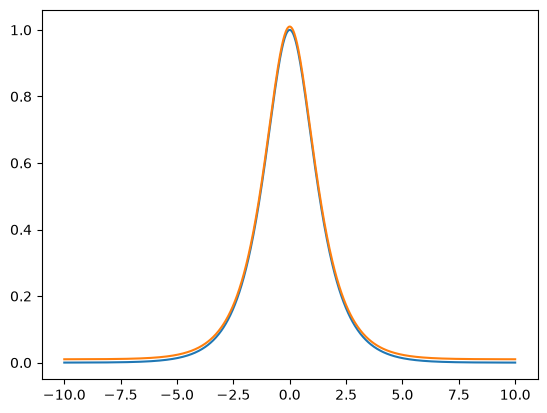

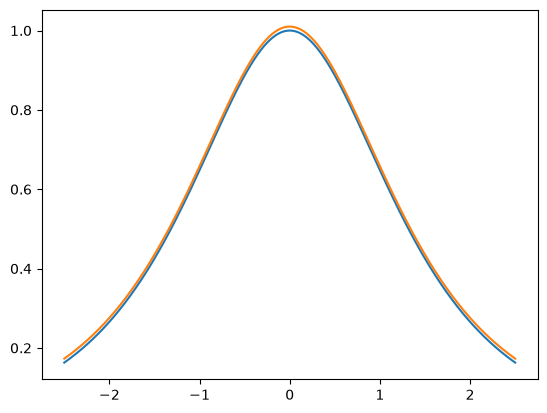

In [210]:
import numpy as np

xs = np.linspace(-10, 10, 1000)
ys = 1./np.cosh(xs)
zs = np.sin(2*np.atan(np.exp(xs))) + 0.01

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.show()


xs = np.linspace(-2.5, 2.5, 1000)
ys = 1./np.cosh(xs)
zs = np.sin(2*np.atan(np.exp(xs))) + 0.01

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.show()


In [211]:
def et(eta) :
    return 1./cosh(eta)

poly, err = chebyfit(et, [-4.0, 4.0], 10, error=True)
nprint(poly,12)
nprint(err,12)
print(polyval(poly,0))
nprint(polyval(poly,0.5))
nprint(polyval(poly,1))

def et2(eta) :
    return 1./cosh(sqrt(eta)) -1


poly2, err = chebyfit(et2, [0.0, 5.0], 4, error=True)
nprint(poly,12)
nprint(err,12)
print(polyval(poly2,0)+1)
print(polyval(poly2,0.25)+1)
nprint(polyval(poly2,1)+1)

print()

t0 = mpf(1.5)
t = taylor(et, t0, 8)
nprint(t[::-1],12)
poly, err = chebyfit(et, [0, 5.0], 10, error=True)
nprint(poly,12)
nprint(err,12)
p, q = pade(t, 4, 4)
nprint(p)
nprint(q)
nprint(polyval(poly,0))
nprint(polyval(poly,1))
nprint(polyval(t[::-1],0-t0))
nprint(polyval(t[::-1],1-t0))
nprint(polyval(p[::-1],0-t0)/polyval(q[::-1],0-t0))
nprint(polyval(p[::-1],1-t0)/polyval(q[::-1],1-t0))

[4.84676140168e-27, 6.60071608268e-5, -2.25535963891e-25, -0.00279557119179, 3.49742302745e-24, 0.0434074937192, -1.9831655186e-23, -0.305528721627, 2.70901650611e-23, 0.944917254663]
0.0550827453374
0.944917254662614
0.871205
0.680066
[4.84676140168e-27, 6.60071608268e-5, -2.25535963891e-25, -0.00279557119179, 3.49742302745e-24, 0.0434074937192, -1.9831655186e-23, -0.305528721627, 2.70901650611e-23, 0.944917254663]
0.0104277077266
0.986476320438033
0.889657802009817
0.656168

[0.00155844499237, -0.000743890243515, -0.005140821581, 0.0189944518376, -0.0324209309713, 0.00540222939376, 0.135730341777, -0.384774933659, 0.425096034942]
[-5.07315380368e-5, 0.00123581524892, -0.0125370624502, 0.0675543536187, -0.199702949201, 0.271015994278, 0.0612441853708, -0.549462754176, 0.00944495599478, 0.999754314456]
0.000447302260977
[0.425096, -0.0733197, -0.00942712, 0.00276442, -0.000123214]
[1.0, 0.73267, 0.321706, 0.0510492, 0.0101552]
0.999754
0.648496
0.975143
0.648052
0.99992
0.648054


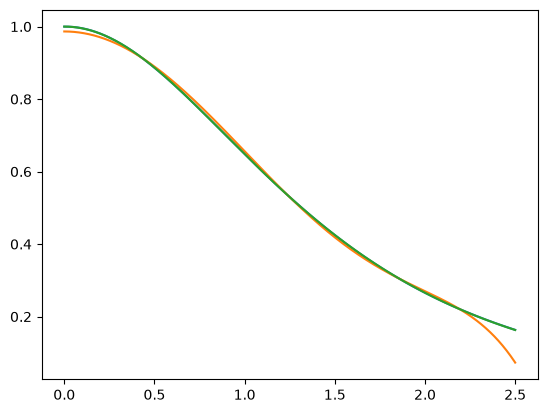

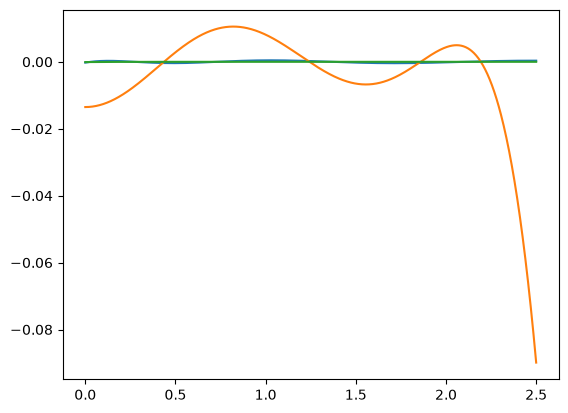

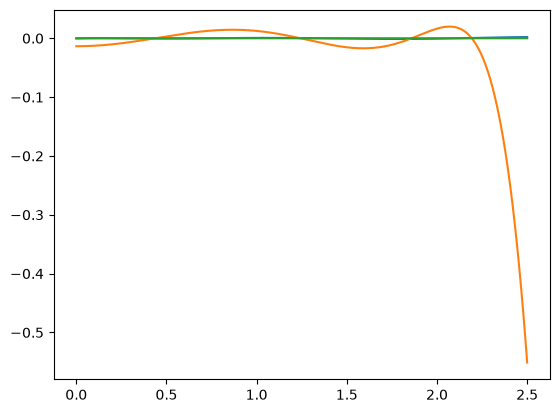

In [212]:
xs = np.linspace(0, 2.5, 1000)
ys = np.fromiter((polyval(poly, xs[n]) for n in range(0,1000)),dtype=float)
zs = np.fromiter((polyval(poly2, xs[n]*xs[n])+1 for n in range(0,1000)),dtype=float)
#zs = np.fromiter((polyval(t[::-1], xs[n]-t0) for n in range(0,1000)),dtype=float)
ps = np.fromiter((polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0) for n in range(0,1000)),dtype=float)

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.plot(xs, ps)
plt.show()

ys = np.fromiter(( polyval(poly, xs[n])-et(xs[n]) for n in range(0,1000)),dtype=float)
zs = np.fromiter(( polyval(poly2, xs[n]*xs[n])+1-et(xs[n]) for n in range(0,1000)),dtype=float)
#zs = np.fromiter(( polyval(t[::-1], xs[n]-t0)-et(xs[n]) for n in range(0,1000)),dtype=float)
ps = np.fromiter(( polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0)-et(xs[n]) for n in range(0,1000)),dtype=float)

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.plot(xs, ps)
plt.show()

ys = np.fromiter(( ((polyval(poly, xs[n])-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=float)
zs = np.fromiter(( ((polyval(poly2, xs[n]*xs[n])+1-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=float)
#zs = np.fromiter(( ((polyval(t[::-1], xs[n]-t0)-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=float)
ps = np.fromiter(( ((polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0)-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=float)

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.plot(xs, ps)
plt.show()

